In [ ]:
import os
os.kill(os.getpid(), 9)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import sys

PROJECT_ROOT = "/content/drive/MyDrive/Colab Notebooks/story-telling"

sys.path.insert(0, PROJECT_ROOT)

print(sys.path[0])

/content/drive/MyDrive/Colab Notebooks/story-telling


In [3]:
import src

print("src imported")
print(src.__file__)

src imported
/content/drive/MyDrive/Colab Notebooks/story-telling/src/__init__.py


In [4]:
from src.models.character import Character

hero = Character("Aiden", "Mage")

print(hero.name)

Aiden


In [5]:
from src.models.story_state import StoryState

from src.memory.memory_manager import MemoryManager

from src.game.inventory import Inventory
from src.game.quest_system import Quest
from src.game.quest_system import QuestManager
from src.game.achievement_system import AchievementManager

from src.world.world_generator import WorldGenerator

from src.npc.npc import NPC

from src.analytics.story_metrics import StoryMetrics

print("Modules Loaded")

Modules Loaded


In [6]:
world_generator = WorldGenerator()

world_data = world_generator.generate_world()

world_data

{'kingdom': 'Aetheria', 'city': 'Silverkeep', 'region': 'Crystal Plains'}

In [7]:
inventory = Inventory()

inventory.add_item("Magic Sword")
inventory.add_item("Health Potion")

inventory.list_items()

['Magic Sword', 'Health Potion']

In [8]:
quest_manager = QuestManager()

main_quest = Quest(
    "Dragon Hunt",
    "Defeat the dragon terrorizing the kingdom."
)

quest_manager.add_quest(main_quest)

print(main_quest.name)

Dragon Hunt


In [9]:
merchant = NPC(
    "Elena",
    "Merchant"
)

print(merchant.name)

Elena


In [10]:
memory = MemoryManager()

memory.add_event(
    "The adventure begins."
)

print(memory.get_history())

The adventure begins.


In [11]:
from dotenv import load_dotenv
import os

load_dotenv("/content/drive/MyDrive/Colab Notebooks/story-telling/.env")

print("Key Loaded:", bool(os.getenv("OPENAI_API_KEY")))

In [37]:
from src.ai.openai_provider import OpenAIProvider
from src.core.config import Config

provider = OpenAIProvider(
    Config.OPENAI_API_KEY
)

In [13]:
story_prompt = f"""
You are a fantasy storyteller.

Hero:
{hero.name}

Role:
{hero.role}

World:
{world_data}

Quest:
Defeat the dragon.

Inventory:
{inventory.list_items()}

Write Chapter 1.
"""

print(story_prompt)


You are a fantasy storyteller.

Hero:
Aiden

Role:
Mage

World:
{'kingdom': 'Aetheria', 'city': 'Silverkeep', 'region': 'Crystal Plains'}

Quest:
Defeat the dragon.

Inventory:
['Magic Sword', 'Health Potion']

Write Chapter 1.



In [14]:
chapter_1 = provider.generate(
    story_prompt
)

print(chapter_1)

### Chapter 1: A Whisper of Flames

The sun began its slow descent behind the jagged peaks of the Frostfire Mountains, bathing the city of Silverkeep in an amber glow. Aiden, a young mage with tousled hair the color of dark copper, stood atop the highest point of the citadel, the ancient spires rising around him like sentinels warding off the encroaching night. From here, he could see the vast expanse of the Crystal Plains—a shimmering sea of violet grass punctuated by clusters of luminescent flowers, whispering a soft lullaby to the evening breeze.

Aiden leaned against the cold stone wall, the weight of his magic sword, an heirloom of his forebears, hanging at his side. It was a blade crafted not just of metal but of enchanted essence, capable of channeling his arcane powers and striking down foes that threatened the peace of Aetheria. In his other hand, he tightly gripped a health potion, its vibrant blue liquid swirling like a storm contained within a crystal vial. Today marked the

In [15]:
memory.add_event(chapter_1)

print("Memory Updated")
print(memory.get_history()[:300])

Memory Updated
The adventure begins.
### Chapter 1: A Whisper of Flames

The sun began its slow descent behind the jagged peaks of the Frostfire Mountains, bathing the city of Silverkeep in an amber glow. Aiden, a young mage with tousled hair the color of dark copper, stood atop the highest point of the citadel, t


In [16]:
metrics = StoryMetrics()

metrics.update(
    chapter_1,
    location=world_data["region"],
    npc=merchant.name
)

metrics.summary()

{'chapters': 1, 'words': 692, 'locations': 1, 'npcs': 1}

In [17]:
from src.game.save_manager import SaveManager

save_manager = SaveManager()

save_manager.save(
    {
        "hero": hero.name,
        "role": hero.role,
        "world": world_data,
        "inventory": inventory.list_items(),
        "story": chapter_1
    },
    "/content/save_game.json"
)

print("Game Saved")

Game Saved


In [18]:
loaded = save_manager.load(
    "/content/save_game.json"
)

loaded.keys()

dict_keys(['hero', 'role', 'world', 'inventory', 'story'])

In [19]:
from src.export.txt_export import TXTExporter

TXTExporter().export(
    chapter_1,
    "/content/chapter1.txt"
)

print("TXT Exported")

TXT Exported


In [21]:
!pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 38.3 MB/s eta 0:00:00


In [22]:
from src.export.pdf_export import PDFExporter

PDFExporter().export(
    chapter_1,
    "/content/chapter1.pdf"
)

print("PDF Exported")

PDF Exported


In [23]:
from google.colab import files

files.download("/content/chapter1.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
files.download("/content/chapter1.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
choices = [
    "Travel through the Crystal Plains",
    "Visit a nearby village",
    "Search for clues about the dragon"
]

for i, c in enumerate(choices, start=1):
    print(f"{i}. {c}")

1. Travel through the Crystal Plains
2. Visit a nearby village
3. Search for clues about the dragon


In [26]:
user_choice = choices[2]

print(user_choice)

Search for clues about the dragon


In [27]:
chapter_2_prompt = f"""
Continue the story.

Previous Chapter:

{chapter_1}

Player Choice:

{user_choice}

Write Chapter 2.
"""

chapter_2 = provider.generate(
    chapter_2_prompt
)

print(chapter_2)

### Chapter 2: The Secrets of the Plains

The moon hung high in the velvet sky, a silver sentinel that illuminated Aiden's path across the Crystal Plains. The soft violet grass shimmered under the celestial glow, casting a dreamy atmosphere that belied the danger lurking within the depths of the shadows. Each step Aiden took was a journey into the unknown, where tales of bravery danced alongside the haunting echoes of the lives taken by the dragon’s fiery wrath.

As he walked, the murmurs of the wind became clearer, revealing whispers of truth and forgotten legends. He knew he would need more than just his sword and courage; to defeat the dragon, he must find knowledge—a clue that would reveal its patterns, its habits, perhaps even its weaknesses. The stories Elara had told him danced in his mind like the flickering flames of a dying fire, reminding him of the old legends surrounding the beast.

With determination setting his jaw, Aiden recalled the tales of the elders—the Dragon’s Lai

In [28]:
memory.add_event(chapter_2)

print(
    f"Memory Length: {len(memory.events)}"
)

Memory Length: 3


In [29]:
metrics.update(
    chapter_2,
    location=world_data["region"],
    npc=merchant.name
)

metrics.summary()

{'chapters': 2, 'words': 1798, 'locations': 1, 'npcs': 1}

Graph Generated


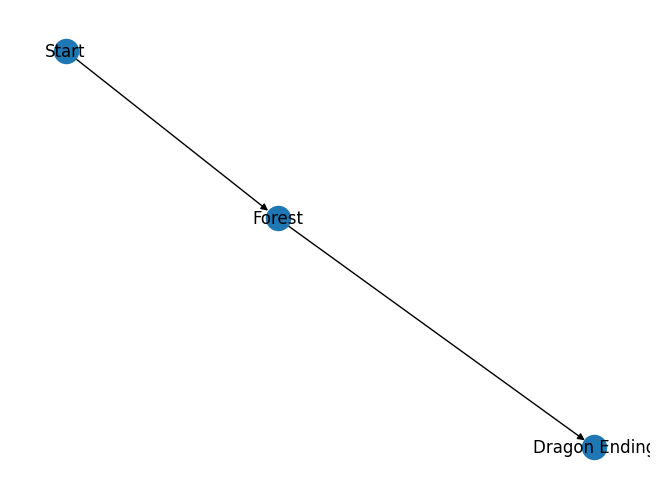

In [30]:
from src.analytics.graph_generator import StoryGraph

graph = StoryGraph()

graph.save_graph(
    "/content/story_graph.png"
)

print("Graph Generated")

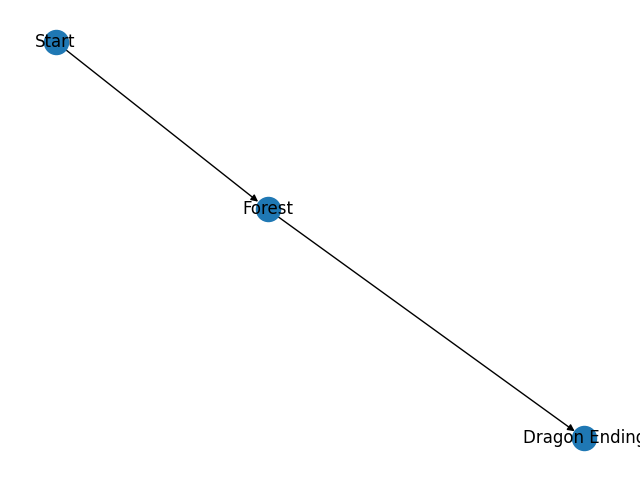

In [31]:
from IPython.display import Image

Image(
    "/content/story_graph.png"
)

In [33]:
from src.game.achievement_system import AchievementManager

achievements = AchievementManager()

achievements.unlock("First Adventure")

print(achievements.get_all())

['First Adventure']


In [35]:
print("=== NarrAIte Portfolio Demo ===")

print("Hero:", hero.name)
print("Role:", hero.role)

print("Inventory:", inventory.list_items())

print("Region:", world_data["region"])

try:
    print("Achievements:", achievements.get_all())
except:
    print("Achievements: None")

print("Story Chapters:",
      metrics.summary().get("chapters", "N/A"))

print("Words Generated:",
      metrics.summary().get("words", "N/A"))

=== NarrAIte Portfolio Demo ===
Hero: Aiden
Role: Mage
Inventory: ['Magic Sword', 'Health Potion']
Region: Crystal Plains
Achievements: ['First Adventure']
Story Chapters: 2
Words Generated: 1798


In [36]:
metrics.summary()

{'chapters': 2, 'words': 1798, 'locations': 1, 'npcs': 1}

In [38]:
from google.colab import files

files.download(
    "/content/drive/MyDrive/Colab Notebooks/story-telling/notebooks/NarrAIte_Main.ipynb"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>